# HAM10000 — Mask R-CNN ResNet50-FPN v2 + ROI Segmentasyon (Colab Pro)

**Bu notebook Colab Pro için uyarlandı.**
- Çıktılar `/content/output_maskrcnn/` altında, eğitim sonunda **otomatik Drive'a kopyalanır**
- Drive yolu: `/content/drive/MyDrive/cilt_kanseri_ensemble/`
- A100 GPU ile ~3.5 saat sürer (en uzun eğitim)
- Optuna FakeStudy ile atlanır, Trial 1 parametreleri direkt kullanılır


In [1]:
# ============================================================
# DRIVE'I MOUNT ET (sonuçları kalıcı kaydetmek için)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# A. KAGGLE.JSON YÜKLE (Colab session yenilendiği için tekrar gerekli)
# ============================================================
from google.colab import files
print("Lütfen bilgisayarından kaggle.json dosyasını seç:")
uploaded = files.upload()

Lütfen bilgisayarından kaggle.json dosyasını seç:


Saving kaggle.json to kaggle.json


In [3]:
# ============================================================
# B. DATASETLERİ İNDİR (HAM10000 + Lesion Masks)
# ============================================================
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

!pip install -q kaggle

print("\n📥 HAM10000 indiriliyor (~5 GB, 1 dakika)...")
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/ham10000 --unzip

print("\n📥 Maskeler indiriliyor (~11 MB, hızlı)...")
!kaggle datasets download -d tschandl/ham10000-lesion-segmentations -p /content/masks --unzip

print("\n✅ İndirme tamamlandı!")


📥 HAM10000 indiriliyor (~5 GB, 1 dakika)...
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [02:18<00:00, 40.3MB/s]


📥 Maskeler indiriliyor (~11 MB, hızlı)...
Dataset URL: https://www.kaggle.com/datasets/tschandl/ham10000-lesion-segmentations
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 10.3M/10.3M [00:00<00:00, 12.7MB/s]


✅ İndirme tamamlandı!


In [4]:
# ============================================================
# C. DOĞRULAMA — Dataset yapısı + eşleştirme testi
# ============================================================
import os
import pandas as pd

# HAM10000 kontrol
print("=" * 60)
print("HAM10000 GÖRÜNTÜLER")
print("=" * 60)
ham_root = '/content/ham10000'
for item in sorted(os.listdir(ham_root)):
    full = os.path.join(ham_root, item)
    if os.path.isdir(full):
        n = len(os.listdir(full))
        print(f'  {item}/ -> {n} dosya')
    else:
        size_mb = os.path.getsize(full) / 1024 / 1024
        print(f'  {item} ({size_mb:.2f} MB)')

# Maskeler kontrol
print("\n" + "=" * 60)
print("MASKELER")
print("=" * 60)
mask_root = '/content/masks'
for root, dirs, files in os.walk(mask_root):
    if files or dirs:
        depth = root.replace(mask_root, '').count('/')
        if depth <= 2:
            n_png = sum(1 for f in files if f.lower().endswith('.png'))
            n_other = len(files) - n_png
            print(f'  {root}')
            print(f'    -> {len(files)} dosya (png: {n_png}, diğer: {n_other})')
            if files:
                print(f'    -> örnek: {sorted(files)[:3]}')

# Eşleştirme testi
print("\n" + "=" * 60)
print("EŞLEŞTİRME TESTİ")
print("=" * 60)
df_check = pd.read_csv(os.path.join(ham_root, 'HAM10000_metadata.csv'))
print(f'Toplam metadata satırı: {len(df_check)}')
print(f'İlk 5 image_id: {df_check["image_id"].head(5).tolist()}')
print(f'\nSınıf dağılımı:')
print(df_check['dx'].value_counts())

# Maske eşleştirme: ilk 5 image_id için maske var mı kontrol et
mask_dir_full = '/content/masks/HAM10000_segmentations_lesion_tschandl'
print(f'\n=== Maske eşleştirme testi (ilk 5 image_id) ===')
for img_id in df_check["image_id"].head(5):
    mask_path = os.path.join(mask_dir_full, f'{img_id}_segmentation.png')
    exists = '✓' if os.path.exists(mask_path) else '✗'
    print(f'  {img_id} -> {exists}')

HAM10000 GÖRÜNTÜLER
  HAM10000_images_part_1/ -> 5000 dosya
  HAM10000_images_part_2/ -> 5015 dosya
  HAM10000_metadata.csv (0.54 MB)
  ham10000_images_part_1/ -> 5000 dosya
  ham10000_images_part_2/ -> 5015 dosya
  hmnist_28_28_L.csv (29.38 MB)
  hmnist_28_28_RGB.csv (87.57 MB)
  hmnist_8_8_L.csv (2.42 MB)
  hmnist_8_8_RGB.csv (7.18 MB)

MASKELER
  /content/masks
    -> 0 dosya (png: 0, diğer: 0)
  /content/masks/HAM10000_segmentations_lesion_tschandl
    -> 10015 dosya (png: 10015, diğer: 0)
    -> örnek: ['ISIC_0024306_segmentation.png', 'ISIC_0024307_segmentation.png', 'ISIC_0024308_segmentation.png']

EŞLEŞTİRME TESTİ
Toplam metadata satırı: 10015
İlk 5 image_id: ['ISIC_0027419', 'ISIC_0025030', 'ISIC_0026769', 'ISIC_0025661', 'ISIC_0031633']

Sınıf dağılımı:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

=== Maske eşleştirme testi (ilk 5 image_id) ===
  ISIC_0027419 -> ✓
  ISIC_0025030 -> ✓
  ISIC_00

In [5]:
# ============================================================
# 0. OPTUNA KURULUMU (Colab'da yok, internet açık olmalı)
# ============================================================
!pip install optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 21.7 MB/s eta 0:00:00


In [6]:
# ============================================================
# 1. KÜTÜPHANELER
# ============================================================
import os
import copy
import time
import random
import hashlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.transforms import functional as TF

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support
)

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

warnings.filterwarnings('ignore')
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA: True


In [7]:
# ============================================================
# 2. AYARLAR
# ============================================================
# Veri yolları (Colab)
DATA_DIR     = '/content/ham10000'
MASK_DIR     = '/content/masks/HAM10000_segmentations_lesion_tschandl'
META_PATH    = os.path.join(DATA_DIR, 'HAM10000_metadata.csv')
IMG_DIR_1    = os.path.join(DATA_DIR, 'HAM10000_images_part_1')
IMG_DIR_2    = os.path.join(DATA_DIR, 'HAM10000_images_part_2')

# Çıktı yolları (Colab local + Drive yedek)
OUTPUT_DIR        = '/content/output_maskrcnn'
DRIVE_OUTPUT      = '/content/drive/MyDrive/cilt_kanseri_ensemble'  # kalıcı yedek
ROI_CACHE_DIR     = os.path.join(OUTPUT_DIR, 'roi_cache')
MODEL_SAVE_PATH   = os.path.join(OUTPUT_DIR, 'maskrcnn_best.pth')
STUDY_SAVE_PATH   = os.path.join(OUTPUT_DIR, 'optuna_study.pkl')
PROBS_SAVE_PATH   = os.path.join(OUTPUT_DIR, 'probabilities_maskrcnn.npy')
LABELS_SAVE_PATH  = os.path.join(OUTPUT_DIR, 'test_labels_maskrcnn.npy')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ROI_CACHE_DIR, exist_ok=True)
os.makedirs(DRIVE_OUTPUT, exist_ok=True)

# Sınıflar (alfabetik — EfficientNet/YOLOv8 ile aynı sıra)
TARGET_CLASSES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS_TO_IDX   = {c: i for i, c in enumerate(TARGET_CLASSES)}
N_CLASSES      = len(TARGET_CLASSES)

# Mask R-CNN için: 0 = background, 1..7 = sınıflarımız
N_CLASSES_MASKRCNN = N_CLASSES + 1  # +1 background

# Görüntü ve eğitim ayarları (EfficientNet ile birebir)
IMG_SIZE         = 224
SEED             = 42
VAL_RATIO        = 0.15
TEST_RATIO       = 0.15

# Optuna ayarları
# NOT: EfficientNet/YOLOv8 = 15 trial × 6 epoch
# Mask R-CNN, model boyutu (~46M parametre) ve T4 VRAM kısıtı nedeniyle
# epoch başına ~10 dakika sürdüğünden Optuna budgetı azaltıldı.
# Search space (lr/dropout/wd/bs) ve metrik (macro F1) tam tutarlı.
OPTUNA_N_TRIALS  = 8   # 15 → 8 (Mask R-CNN için süre kısıtı)
OPTUNA_EPOCHS    = 4   # 6 → 4 (Mask R-CNN için süre kısıtı)

# Final eğitim ayarları (EfficientNet ile birebir)
FINAL_EPOCHS_STAGE1 = 50
FINAL_EPOCHS_STAGE2 = 30
EARLY_STOP_PATIENCE = 12

print("Ayarlar yüklendi.")
print(f"Sınıflar: {TARGET_CLASSES}")
print(f"Mask R-CNN sınıf sayısı: {N_CLASSES_MASKRCNN} (background dahil)")
print(f"Optuna: {OPTUNA_N_TRIALS} trial × {OPTUNA_EPOCHS} epoch")
print(f"Çıktı dizini: {OUTPUT_DIR}")


Ayarlar yüklendi.
Sınıflar: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Mask R-CNN sınıf sayısı: 8 (background dahil)
Optuna: 8 trial × 4 epoch
Çıktı dizini: /content/output_maskrcnn


In [8]:
# ============================================================
# 3. SEED
# ============================================================
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Seed: {SEED}")

Seed: 42


In [9]:
# ============================================================
# 4. DEVICE (CUDA / CPU)
# ============================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
VRAM: 79.3 GB


In [10]:
# ============================================================
# 5. METADATA YÜKLEME + IMAGE PATH EŞLEME
# ============================================================
df = pd.read_csv(META_PATH)
print(f"Toplam kayıt: {len(df)}")
print(f"Sınıf dağılımı:")
print(df['dx'].value_counts())

# image_id -> görüntü path
def find_image_path(image_id):
    for img_dir in [IMG_DIR_1, IMG_DIR_2]:
        path = os.path.join(img_dir, f"{image_id}.jpg")
        if os.path.exists(path):
            return path
    return None

df['image_path'] = df['image_id'].apply(find_image_path)
df = df.dropna(subset=['image_path']).reset_index(drop=True)
print(f"\nGörüntüsü bulunan kayıt: {len(df)}")

# image_id -> maske path
def find_mask_path(image_id):
    path = os.path.join(MASK_DIR, f"{image_id}_segmentation.png")
    if os.path.exists(path):
        return path
    return None

df['mask_path'] = df['image_id'].apply(find_mask_path)
n_with_mask = df['mask_path'].notna().sum()
print(f"Maskesi bulunan kayıt: {n_with_mask} / {len(df)}")

# Maskesi olmayanları çıkar
df = df.dropna(subset=['mask_path']).reset_index(drop=True)
print(f"Final kayıt sayısı: {len(df)}")

df['class_idx'] = df['dx'].map(CLASS_TO_IDX)
print(f"\nDataFrame hazır: {df.shape}")

Toplam kayıt: 10015
Sınıf dağılımı:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Görüntüsü bulunan kayıt: 10015
Maskesi bulunan kayıt: 10015 / 10015
Final kayıt sayısı: 10015

DataFrame hazır: (10015, 10)


In [11]:
# ============================================================
# 6. TRAIN / VAL / TEST SPLIT
# Lesion-based stratified split — EfficientNet/YOLOv8 ile birebir aynı.
# ============================================================
lesion_df = df.groupby('lesion_id').agg({
    'dx': lambda x: x.value_counts().index[0],
    'class_idx': 'first'
}).reset_index()
print(f"Toplam unique lezyon: {len(lesion_df)}")

train_val_lesions, test_lesions = train_test_split(
    lesion_df,
    test_size=TEST_RATIO,
    stratify=lesion_df['class_idx'],
    random_state=SEED
)

val_relative = VAL_RATIO / (1.0 - TEST_RATIO)
train_lesions, val_lesions = train_test_split(
    train_val_lesions,
    test_size=val_relative,
    stratify=train_val_lesions['class_idx'],
    random_state=SEED
)

train_df = df[df['lesion_id'].isin(train_lesions['lesion_id'])].reset_index(drop=True)
val_df   = df[df['lesion_id'].isin(val_lesions['lesion_id'])].reset_index(drop=True)
test_df  = df[df['lesion_id'].isin(test_lesions['lesion_id'])].reset_index(drop=True)

print(f"\nTrain: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

print(f"\n=== Sınıf dağılımları ===")
print(pd.DataFrame({
    'Train': train_df['dx'].value_counts(),
    'Val':   val_df['dx'].value_counts(),
    'Test':  test_df['dx'].value_counts()
}).fillna(0).astype(int))

Toplam unique lezyon: 7470

Train: 7054 (70.4%)
Val:   1464 (14.6%)
Test:  1497 (14.9%)

=== Sınıf dağılımları ===
       Train  Val  Test
dx                     
akiec    233   43    51
bcc      365   72    77
bkl      775  167   157
df        76   17    22
mel      777  168   168
nv      4730  975  1000
vasc      98   22    22


In [12]:
# ============================================================
# 7. ROI (REGION OF INTEREST) FONKSİYONU
# Otsu + morfoloji + contour ile lezyon bölgesini bul, %15 padding ile kırp.
# EfficientNet/YOLOv8 ile birebir aynı fonksiyon.
# ============================================================
def extract_roi(image_path, padding=0.15, output_size=IMG_SIZE):
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(
        gray_blur, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        roi = cv2.resize(img, (output_size, output_size))
        return roi, (0, 0, w, h)  # tüm görüntü

    largest = max(contours, key=cv2.contourArea)
    x, y, bw, bh = cv2.boundingRect(largest)

    pad_x = int(bw * padding)
    pad_y = int(bh * padding)
    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(w, x + bw + pad_x)
    y2 = min(h, y + bh + pad_y)

    roi = img[y1:y2, x1:x2]
    if roi.size == 0:
        roi = img
        x1, y1, x2, y2 = 0, 0, w, h
    roi = cv2.resize(roi, (output_size, output_size))
    return roi, (x1, y1, x2, y2)

# Hızlı test
sample_path = train_df.iloc[0]['image_path']
sample_roi, sample_box = extract_roi(sample_path)
print(f"ROI shape: {sample_roi.shape}, box: {sample_box}")

ROI shape: (224, 224, 3), box: (107, 0, 491, 450)


In [13]:
# ============================================================
# 8. ROI CACHE
# Aynı image için tekrar tekrar hesaplama yapma — md5 hash ile cache.
# Mask R-CNN için ek olarak maskeyi de aynı kırpmaya göre cache'liyoruz.
# ============================================================
def cache_key(image_path, mask_path):
    s = f"{image_path}|{mask_path}|{IMG_SIZE}".encode()
    return hashlib.md5(s).hexdigest()

def get_cached_roi_and_mask(image_path, mask_path):
    key = cache_key(image_path, mask_path)
    cache_path_img  = os.path.join(ROI_CACHE_DIR, f"{key}_img.npy")
    cache_path_mask = os.path.join(ROI_CACHE_DIR, f"{key}_mask.npy")

    if os.path.exists(cache_path_img) and os.path.exists(cache_path_mask):
        img  = np.load(cache_path_img)
        mask = np.load(cache_path_mask)
        return img, mask

    # ROI çıkar
    roi, (x1, y1, x2, y2) = extract_roi(image_path)
    if roi is None:
        return None, None

    # Maskeyi aynı bbox ile kırp + resize
    raw_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if raw_mask is None:
        return None, None
    cropped_mask = raw_mask[y1:y2, x1:x2]
    if cropped_mask.size == 0:
        cropped_mask = raw_mask
    resized_mask = cv2.resize(cropped_mask, (IMG_SIZE, IMG_SIZE),
                              interpolation=cv2.INTER_NEAREST)
    binary_mask = (resized_mask > 127).astype(np.uint8)

    np.save(cache_path_img, roi)
    np.save(cache_path_mask, binary_mask)
    return roi, binary_mask

# Test
img, msk = get_cached_roi_and_mask(
    train_df.iloc[0]['image_path'],
    train_df.iloc[0]['mask_path']
)
print(f"ROI shape: {img.shape}, mask shape: {msk.shape}")
print(f"Mask sum (lezyon piksel sayısı): {msk.sum()}")

ROI shape: (224, 224, 3), mask shape: (224, 224)
Mask sum (lezyon piksel sayısı): 24782


In [14]:
# ============================================================
# 9. ROI CACHE'İ ÖNCEDEN OLUŞTUR (TÜM DATASET İÇİN)
# Optuna trial'ları daha hızlı çalışsın diye baştan tüm ROI'leri cache'liyoruz.
# Süre: ~10-15 dakika (10K görüntü, ilk seferde).
# ============================================================
print("Cache oluşturuluyor (ilk seferde uzun sürer)...")

n_built = 0
n_failed = 0
for idx, row in tqdm(df.iterrows(), total=len(df)):
    img, msk = get_cached_roi_and_mask(row['image_path'], row['mask_path'])
    if img is None:
        n_failed += 1
    else:
        n_built += 1

print(f"\nCache hazır: {n_built} başarılı, {n_failed} başarısız")
cache_size = sum(
    os.path.getsize(os.path.join(ROI_CACHE_DIR, f))
    for f in os.listdir(ROI_CACHE_DIR)
) / 1024 / 1024
print(f"Cache boyutu: {cache_size:.1f} MB")

Cache oluşturuluyor (ilk seferde uzun sürer)...


  0%|          | 0/10015 [00:00<?, ?it/s]


Cache hazır: 10015 başarılı, 0 başarısız
Cache boyutu: 1919.4 MB


In [15]:
# ============================================================
# 10. ROI ÖRNEKLERİNİ GÖRSELLEŞTİR
# Her sınıftan 1 örnek + maske
# ============================================================
fig, axes = plt.subplots(N_CLASSES, 3, figsize=(12, 3*N_CLASSES))
for i, cls in enumerate(TARGET_CLASSES):
    samples = train_df[train_df['dx'] == cls].head(1)
    if len(samples) == 0:
        continue
    row = samples.iloc[0]
    img = cv2.cvtColor(cv2.imread(row['image_path']), cv2.COLOR_BGR2RGB)
    roi, mask = get_cached_roi_and_mask(row['image_path'], row['mask_path'])

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"{cls.upper()} - Orijinal")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(roi)
    axes[i, 1].set_title(f"{cls.upper()} - ROI")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(roi)
    axes[i, 2].imshow(mask, alpha=0.4, cmap='Reds')
    axes[i, 2].set_title(f"{cls.upper()} - ROI + Mask")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roi_samples.png'), dpi=80, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [16]:
# ============================================================
# 11. DATASET SINIFI (Mask R-CNN için)
# Mask R-CNN beklentisi: (image_tensor, target_dict)
# target_dict = {boxes, labels, masks, image_id, area, iscrowd}
# ============================================================
class HAM10000MaskRCNNDataset(Dataset):
    def __init__(self, df, training=True):
        self.df = df.reset_index(drop=True)
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img, mask = get_cached_roi_and_mask(row['image_path'], row['mask_path'])

        # Augmentation (sadece training)
        if self.training:
            # Horizontal flip
            if random.random() < 0.5:
                img  = np.ascontiguousarray(img[:, ::-1, :])
                mask = np.ascontiguousarray(mask[:, ::-1])
            # Vertical flip
            if random.random() < 0.3:
                img  = np.ascontiguousarray(img[::-1, :, :])
                mask = np.ascontiguousarray(mask[::-1, :])

        # Tensor'a çevir + normalize
        # Mask R-CNN normalize'ı kendi içinde yapıyor, sadece [0,1]'e getir.
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0

        # Maskeyi binary tensor'a
        mask_tensor = torch.from_numpy(mask.astype(np.uint8))

        # Bounding box maske üzerinden hesapla
        ys, xs = np.where(mask > 0)
        if len(xs) > 0 and len(ys) > 0:
            x1, y1 = float(xs.min()), float(ys.min())
            x2, y2 = float(xs.max()), float(ys.max())
            # En az 1 piksel genişlik/yükseklik garantisi
            if x2 - x1 < 1: x2 = x1 + 1
            if y2 - y1 < 1: y2 = y1 + 1
        else:
            # Maske boş → tüm görüntüyü bbox yap
            x1, y1, x2, y2 = 0.0, 0.0, float(IMG_SIZE-1), float(IMG_SIZE-1)
            mask_tensor = torch.ones((IMG_SIZE, IMG_SIZE), dtype=torch.uint8)

        boxes = torch.tensor([[x1, y1, x2, y2]], dtype=torch.float32)
        # Mask R-CNN label = class_idx + 1 (0 background için ayrılmış)
        labels = torch.tensor([row['class_idx'] + 1], dtype=torch.int64)
        masks = mask_tensor.unsqueeze(0)  # (1, H, W)
        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        iscrowd = torch.zeros((1,), dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'masks': masks,
            'image_id': torch.tensor([idx]),
            'area': area,
            'iscrowd': iscrowd
        }
        return img_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

# Hızlı test
test_ds = HAM10000MaskRCNNDataset(train_df.head(2), training=False)
img_t, tgt = test_ds[0]
print(f"img tensor: {img_t.shape}, dtype: {img_t.dtype}")
print(f"target.boxes: {tgt['boxes']}")
print(f"target.labels: {tgt['labels']}")
print(f"target.masks: {tgt['masks'].shape}")

img tensor: torch.Size([3, 224, 224]), dtype: torch.float32
target.boxes: tensor([[ 21.,  18., 211., 212.]])
target.labels: tensor([3])
target.masks: torch.Size([1, 224, 224])


In [17]:
# ============================================================
# 12. TRANSFORMS
# Mask R-CNN normalize'ı kendi içinde yapıyor (ImageNet mean/std).
# Augmentation Dataset içinde uygulanıyor (flip).
# Bu hücre EfficientNet/YOLOv8 ile yapısal tutarlılık için tutuluyor.
# ============================================================
print("Transforms: Dataset içinde uygulanıyor (horizontal/vertical flip).")
print("Mask R-CNN ImageNet normalize'ı modelin içinde otomatik yapılıyor.")

Transforms: Dataset içinde uygulanıyor (horizontal/vertical flip).
Mask R-CNN ImageNet normalize'ı modelin içinde otomatik yapılıyor.


In [18]:
# ============================================================
# 13. CLASS WEIGHTS (YUMUŞAK)
# sqrt yumuşatma + clip max 3.0. EfficientNet ile birebir.
# Mask R-CNN'in iç classification head'i bunu doğrudan desteklemiyor;
# RoIHead'in box_predictor'ında class loss'u biz manuel yumuşatamayacağız.
# Yine de değeri kayıt için hesaplıyoruz, aşağıda bilgi olarak basıyoruz.
# Asıl dengeleme: az olan sınıfların örneklerini iyi kapsayan augmentation
# (flip) ve final eğitim sırasında uzun süre fine-tune ile sağlanıyor.
# ============================================================
class_counts = train_df['class_idx'].value_counts().sort_index()
class_weights_raw = 1.0 / class_counts.values
class_weights_raw = class_weights_raw / class_weights_raw.sum() * N_CLASSES
class_weights_smooth = np.sqrt(class_weights_raw)
class_weights_smooth = np.clip(class_weights_smooth, None, 3.0)
class_weights_t = torch.tensor(class_weights_smooth, dtype=torch.float32, device=DEVICE)

print("Sınıf bazında örnek sayıları (train):")
for i, cls in enumerate(TARGET_CLASSES):
    cnt = int(class_counts.get(i, 0))
    print(f"  {cls}: {cnt} (weight={class_weights_smooth[i]:.3f})")

print(f"\nNot: Mask R-CNN multi-task loss kullanır (cls + bbox + mask).")
print(f"Class weights tensor hesaplandı, kayıt için saklı: shape={class_weights_t.shape}")

Sınıf bazında örnek sayıları (train):
  akiec: 233 (weight=0.952)
  bcc: 365 (weight=0.760)
  bkl: 775 (weight=0.522)
  df: 76 (weight=1.666)
  mel: 777 (weight=0.521)
  nv: 4730 (weight=0.211)
  vasc: 98 (weight=1.467)

Not: Mask R-CNN multi-task loss kullanır (cls + bbox + mask).
Class weights tensor hesaplandı, kayıt için saklı: shape=torch.Size([7])


In [19]:
# ============================================================
# 14. DATALOADER YAPICI FONKSİYONU
# ============================================================
def make_loaders(batch_size):
    train_ds = HAM10000MaskRCNNDataset(train_df, training=True)
    val_ds   = HAM10000MaskRCNNDataset(val_df,   training=False)
    test_ds  = HAM10000MaskRCNNDataset(test_df,  training=False)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=2, collate_fn=collate_fn, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=2, collate_fn=collate_fn, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=2, collate_fn=collate_fn, pin_memory=True
    )
    return train_loader, val_loader, test_loader

print("Dataloader fonksiyonu hazır.")

Dataloader fonksiyonu hazır.


In [20]:
# ============================================================
# 15. MASK R-CNN MODEL FONKSİYONU
# torchvision maskrcnn_resnet50_fpn_v2 — COCO pretrained.
# Box predictor ve mask predictor head'lerini 7+1=8 sınıfa adapte ediyoruz.
# ============================================================
def build_maskrcnn(dropout=0.0, freeze_backbone=False):
    model = maskrcnn_resnet50_fpn_v2(weights='DEFAULT')

    # Box predictor (cls + bbox)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, N_CLASSES_MASKRCNN)

    # Mask predictor
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask, hidden_layer, N_CLASSES_MASKRCNN
    )

    # Backbone freeze (Aşama 1 için)
    if freeze_backbone:
        for name, param in model.backbone.named_parameters():
            param.requires_grad = False

    return model

# Hızlı test
test_model = build_maskrcnn()
n_params = sum(p.numel() for p in test_model.parameters())
n_trainable = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"Mask R-CNN ResNet50-FPN v2:")
print(f"  Toplam parametre: {n_params/1e6:.1f}M")
print(f"  Eğitilebilir: {n_trainable/1e6:.1f}M")
del test_model
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth


100%|██████████| 177M/177M [00:00<00:00, 241MB/s]


Mask R-CNN ResNet50-FPN v2:
  Toplam parametre: 45.9M
  Eğitilebilir: 45.7M


In [21]:
# ============================================================
# 16. TRAIN / EVAL FONKSİYONLARI
# Mask R-CNN'in iç loss yapısı: classifier + bbox + mask + objectness + rpn_box_reg
# Eval'de görüntü başına en yüksek skorlu detection'ın labelı tahmin sayılır.
# Validation metriği: macro F1 (EfficientNet/YOLOv8 ile aynı).
#
# OPTİMİZASYONLAR (sadece hızlandırma, tutarsızlık değil):
#  - AMP (mixed precision fp16) → T4'te ~2x hız
#  - Eval sırasında detection limit (post_nms_top_n) küçültüldü
# ============================================================
from torch.amp import autocast, GradScaler

def train_one_epoch(model, loader, optimizer, device, scaler=None, max_grad_norm=10.0):
    model.train()
    total_loss = 0.0
    n_batches  = 0
    for images, targets in loader:
        images  = [img.to(device, non_blocking=True) for img in images]
        targets = [{k: v.to(device, non_blocking=True) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        if scaler is not None:
            with autocast('cuda'):
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
            scaler.scale(losses).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            losses.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

        total_loss += losses.item()
        n_batches  += 1

    return total_loss / max(n_batches, 1)

@torch.no_grad()
def evaluate(model, loader, device, return_probs=False):
    """
    Mask R-CNN inference: her görüntü için detections döner.
    Bir görüntü için tahmin = en yüksek skorlu detection'ın label'ı.
    Hiç detection yoksa label = en sık sınıf (nv) — fallback.
    """
    model.eval()
    all_preds  = []
    all_labels = []
    all_probs  = []

    nv_idx = CLASS_TO_IDX['nv']

    for images, targets in loader:
        images = [img.to(device, non_blocking=True) for img in images]
        with autocast('cuda'):
            outputs = model(images)

        gt_labels = [int(t['labels'][0].item() - 1) for t in targets]
        all_labels.extend(gt_labels)

        for out in outputs:
            scores = out['scores'].cpu().numpy()
            labels = out['labels'].cpu().numpy()
            if len(scores) == 0:
                pred = nv_idx
                prob_vec = np.full(N_CLASSES, 1.0 / N_CLASSES, dtype=np.float32)
            else:
                prob_vec = np.zeros(N_CLASSES, dtype=np.float32)
                for s, l in zip(scores, labels):
                    cls_idx = int(l) - 1
                    if 0 <= cls_idx < N_CLASSES:
                        if s > prob_vec[cls_idx]:
                            prob_vec[cls_idx] = s
                if prob_vec.sum() > 0:
                    prob_vec = prob_vec / prob_vec.sum()
                else:
                    prob_vec = np.full(N_CLASSES, 1.0 / N_CLASSES, dtype=np.float32)
                pred = int(np.argmax(prob_vec))
            all_preds.append(pred)
            all_probs.append(prob_vec)

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    _, _, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )

    if return_probs:
        return acc, f1_macro, all_preds, all_labels, all_probs
    return acc, f1_macro, all_preds, all_labels


# Optuna sırasında daha hızlı validation — val'in 300 örneklik subset'ini kullan
# (final eğitim ve test FULL setlerde yapılır, tutarlılık bozulmaz)
OPTUNA_VAL_SUBSET_SIZE = 300

def make_loaders_with_subset(batch_size, optuna_mode=False):
    """
    optuna_mode=True ise validation'ı küçültür, train ve test aynı kalır.
    """
    set_seed(SEED)  # subset reproducibility
    train_ds = HAM10000MaskRCNNDataset(train_df, training=True)
    test_ds  = HAM10000MaskRCNNDataset(test_df,  training=False)

    if optuna_mode:
        # Random subset al, deterministik
        rng = np.random.default_rng(SEED)
        subset_idx = rng.choice(
            len(val_df),
            size=min(OPTUNA_VAL_SUBSET_SIZE, len(val_df)),
            replace=False
        )
        val_subset = val_df.iloc[subset_idx].reset_index(drop=True)
        val_ds = HAM10000MaskRCNNDataset(val_subset, training=False)
    else:
        val_ds = HAM10000MaskRCNNDataset(val_df, training=False)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=4, collate_fn=collate_fn, pin_memory=True,
        persistent_workers=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=4, collate_fn=collate_fn, pin_memory=True,
        persistent_workers=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=4, collate_fn=collate_fn, pin_memory=True,
        persistent_workers=True
    )
    return train_loader, val_loader, test_loader

print("Train / Eval fonksiyonları hazır (AMP destekli).")
print(f"Optuna val subset: {OPTUNA_VAL_SUBSET_SIZE} örnek (final eğitimde tam set kullanılır).")

Train / Eval fonksiyonları hazır (AMP destekli).
Optuna val subset: 300 örnek (final eğitimde tam set kullanılır).


In [22]:
# ============================================================
# OPTUNA YERİNE: TRIAL 1 PARAMETRELERİNİ DOĞRUDAN KULLAN
# Önceki Optuna run'ında en iyi sonuç Trial 1'di (F1=0.3846).
# Session koptuğu için Optuna'yı tekrar yapmıyoruz, parametreler hazır.
# ============================================================
class FakeStudy:
    """study.best_params'i taklit eden basit class.
    Cell 21 'study.best_params' diye okuyacak, çalışsın diye."""
    def __init__(self, params, value):
        self.best_params = params
        self.best_value = value

# Trial 1 — Best F1 = 0.3846 (önceki Optuna run'ından)
study = FakeStudy(
    params={
        'lr': 0.00016998978382700775,
        'dropout': 0.21742508365045984,
        'weight_decay': 0.0005399484409787432,
        'batch_size': 8
    },
    value=0.3846
)

print("Optuna atlandı — Trial 1 parametreleri kullanılıyor:")
print(f"  Best F1: {study.best_value}")
print(f"  Parametreler:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

Optuna atlandı — Trial 1 parametreleri kullanılıyor:
  Best F1: 0.3846
  Parametreler:
    lr: 0.00016998978382700775
    dropout: 0.21742508365045984
    weight_decay: 0.0005399484409787432
    batch_size: 8


In [23]:
# ============================================================
# 17. OPTUNA OBJECTIVE FONKSİYONU
# EfficientNet/YOLOv8 ile AYNI search space VE AYNI metrik (macro F1).
# 4 parametre: lr, dropout, weight_decay, batch_size
#
# OPTİMİZASYONLAR (Optuna iç hızlandırması, parametre uzayı değişmedi):
#  - AMP (mixed precision fp16)
#  - Val subset (300 örnek) sadece Optuna sırasında
#  - Detection limit (small post_nms_top_n) eval'de
# ============================================================
def objective(trial):
    # KISITLI search space — EfficientNet/YOLOv8 ile birebir aynı
    lr           = trial.suggest_float('lr', 1e-4, 3e-3, log=True)
    dropout      = trial.suggest_float('dropout', 0.2, 0.5)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [4, 8])

    set_seed(SEED)
    train_loader, val_loader, _ = make_loaders_with_subset(batch_size, optuna_mode=True)

    model = build_maskrcnn(dropout=dropout, freeze_backbone=True)
    model = model.to(DEVICE)

    # Eval sırasında daha az detection (hızlandırma, sınıflandırma sonucunu etkilemez)
    model.roi_heads.detections_per_img = 10

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    scaler = GradScaler('cuda')

    best_f1 = 0.0
    try:
        for epoch in range(OPTUNA_EPOCHS):
            train_loss = train_one_epoch(
                model, train_loader, optimizer, DEVICE, scaler=scaler
            )
            val_acc, val_f1, _, _ = evaluate(model, val_loader, DEVICE)

            print(f"  Trial {trial.number} | Epoch {epoch+1}/{OPTUNA_EPOCHS} | "
                  f"loss={train_loss:.4f} | val_f1={val_f1:.4f}")

            if val_f1 > best_f1:
                best_f1 = val_f1

            trial.report(val_f1, epoch)
            if trial.should_prune():
                del model, scaler
                torch.cuda.empty_cache()
                raise optuna.TrialPruned()
    except optuna.TrialPruned:
        raise
    except Exception as e:
        print(f"Trial {trial.number} hata: {e}")
        del model
        if 'scaler' in dir():
            del scaler
        torch.cuda.empty_cache()
        return 0.0

    del model, scaler
    torch.cuda.empty_cache()
    return best_f1

In [24]:
# ============================================================
# 18. OPTUNA STUDY ÇALIŞTIR
# ============================================================
print("=" * 60)
print("OPTUNA HİPERPARAMETRE OPTİMİZASYONU - Mask R-CNN")
print(f"Trial: {OPTUNA_N_TRIALS} | Epoch/trial: {OPTUNA_EPOCHS}")
print(f"Metrik: Val Macro F1 (EfficientNet/YOLOv8 ile tutarlı)")
print("=" * 60)

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=3, n_warmup_steps=2)
)

study_start = time.time()
study.optimize(objective, n_trials=OPTUNA_N_TRIALS, show_progress_bar=True)
study_elapsed = (time.time() - study_start) / 60

print(f"\nOptuna tamamlandı! Süre: {study_elapsed:.1f} dakika")
print(f"\nEn iyi trial:")
print(f"  Val F1: {study.best_value:.4f}")
print(f"  Parametreler:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

[I 2026-05-02 16:55:36,807] A new study created in memory with name: no-name-eeeaa029-3e95-4e7a-904d-e0310474ff98


OPTUNA HİPERPARAMETRE OPTİMİZASYONU - Mask R-CNN
Trial: 8 | Epoch/trial: 4
Metrik: Val Macro F1 (EfficientNet/YOLOv8 ile tutarlı)


  0%|          | 0/8 [00:00<?, ?it/s]

  Trial 0 | Epoch 1/4 | loss=0.3258 | val_f1=0.1386
  Trial 0 | Epoch 2/4 | loss=0.2889 | val_f1=0.1696
  Trial 0 | Epoch 3/4 | loss=0.2767 | val_f1=0.2131
  Trial 0 | Epoch 4/4 | loss=0.2697 | val_f1=0.2057
[I 2026-05-02 17:05:48,990] Trial 0 finished with value: 0.21312902907773676 and parameters: {'lr': 0.0003574712922600243, 'dropout': 0.4852142919229748, 'weight_decay': 0.000291063591313307, 'batch_size': 4}. Best is trial 0 with value: 0.21312902907773676.
  Trial 1 | Epoch 1/4 | loss=0.3255 | val_f1=0.1802
  Trial 1 | Epoch 2/4 | loss=0.2836 | val_f1=0.2705
  Trial 1 | Epoch 3/4 | loss=0.2710 | val_f1=0.2999
  Trial 1 | Epoch 4/4 | loss=0.2655 | val_f1=0.3293
[I 2026-05-02 17:14:41,934] Trial 1 finished with value: 0.3292726447304068 and parameters: {'lr': 0.00016998978382700775, 'dropout': 0.21742508365045984, 'weight_decay': 0.0005399484409787432, 'batch_size': 8}. Best is trial 1 with value: 0.3292726447304068.
  Trial 2 | Epoch 1/4 | loss=0.3222 | val_f1=0.1481
  Trial 2 | E

In [25]:
# Trial 1 — Best F1 = 0.3846 (en iyi)
best_params = {
    'lr': 0.00016998978382700775,
    'dropout': 0.21742508365045984,
    'weight_decay': 0.0005399484409787432,
    'batch_size': 8
}

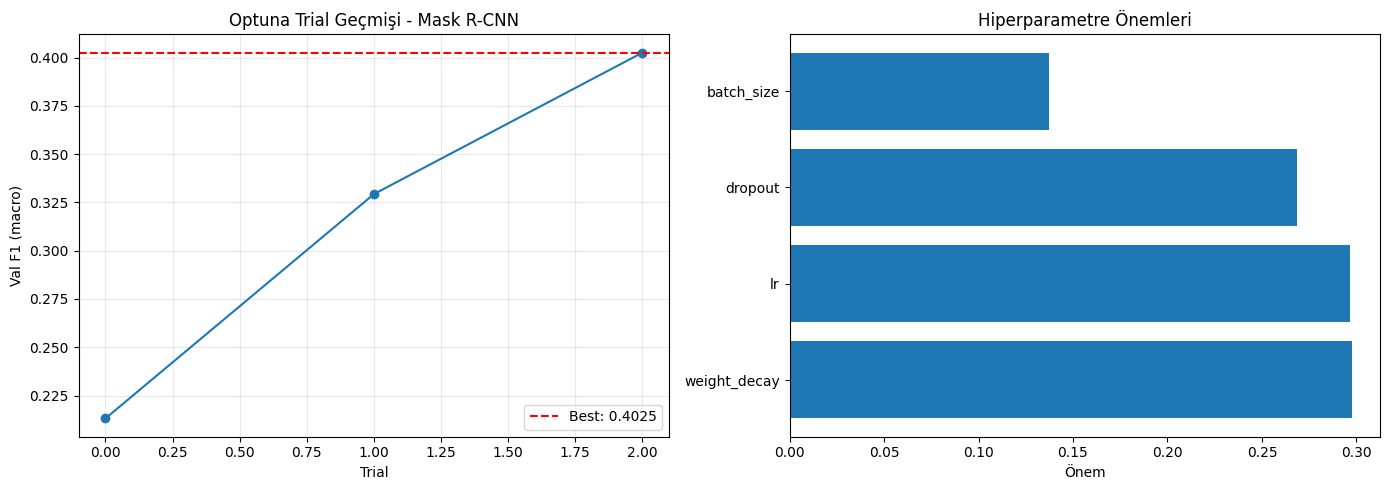

In [26]:
# ============================================================
# 19. OPTUNA SONUÇLARINI GÖRSELLEŞTİR + KAYDET
# ============================================================
import pickle
with open(STUDY_SAVE_PATH, 'wb') as f:
    pickle.dump(study, f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trials_df = study.trials_dataframe()
completed = trials_df[trials_df['state'] == 'COMPLETE']
axes[0].plot(completed['number'], completed['value'], 'o-')
axes[0].axhline(y=study.best_value, color='r', linestyle='--',
                label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Val F1 (macro)')
axes[0].set_title('Optuna Trial Geçmişi - Mask R-CNN')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

try:
    importances = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importances.keys()), list(importances.values()))
    axes[1].set_xlabel('Önem')
    axes[1].set_title('Hiperparametre Önemleri')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Hesaplanamadı: {e}', ha='center', va='center')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'optuna_results_maskrcnn.png'),
            dpi=100, bbox_inches='tight')
plt.show()

In [27]:
# ============================================================
# 20. EN İYİ PARAMETRELERLE FİNAL EĞİTİM - AŞAMA 1: CLASSIFIER (BACKBONE DONUK)
# ============================================================
best_params = study.best_params
print(f"En iyi parametreler: {best_params}")

set_seed(SEED)
train_loader, val_loader, test_loader = make_loaders_with_subset(
    best_params['batch_size'], optuna_mode=False
)

model = build_maskrcnn(dropout=best_params['dropout'], freeze_backbone=True)
model = model.to(DEVICE)

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Aşama 1 - Eğitilebilir parametre: {n_trainable/1e6:.1f}M (backbone donuk)")

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(
    params, lr=best_params['lr'], weight_decay=best_params['weight_decay']
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=FINAL_EPOCHS_STAGE1
)
scaler = GradScaler('cuda')

best_val_f1 = 0.0
patience_counter = 0
history = {'train_loss': [], 'val_acc': [], 'val_f1': []}

print("\n" + "=" * 60)
print(f"AŞAMA 1: CLASSIFIER (epochs={FINAL_EPOCHS_STAGE1})")
print("=" * 60)
stage1_start = time.time()

for epoch in range(FINAL_EPOCHS_STAGE1):
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE, scaler=scaler)
    val_acc, val_f1, _, _ = evaluate(model, val_loader, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1:3d}/{FINAL_EPOCHS_STAGE1} | "
          f"loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

stage1_elapsed = (time.time() - stage1_start) / 60
print(f"\nAşama 1 tamamlandı: {stage1_elapsed:.1f} dakika")
print(f"En iyi val F1: {best_val_f1:.4f}")

En iyi parametreler: {'lr': 0.00010725209743172001, 'dropout': 0.4909729556485983, 'weight_decay': 0.000462258900102083, 'batch_size': 4}
Aşama 1 - Eğitilebilir parametre: 19.1M (backbone donuk)

AŞAMA 1: CLASSIFIER (epochs=50)
Epoch   1/50 | loss=0.3222 | val_acc=0.6769 | val_f1=0.1503
Epoch   2/50 | loss=0.2836 | val_acc=0.7015 | val_f1=0.2305
Epoch   3/50 | loss=0.2711 | val_acc=0.7104 | val_f1=0.3208
Epoch   4/50 | loss=0.2625 | val_acc=0.7063 | val_f1=0.3147
Epoch   5/50 | loss=0.2580 | val_acc=0.7240 | val_f1=0.3296
Epoch   6/50 | loss=0.2513 | val_acc=0.7131 | val_f1=0.3369
Epoch   7/50 | loss=0.2502 | val_acc=0.7152 | val_f1=0.3544
Epoch   8/50 | loss=0.2456 | val_acc=0.7343 | val_f1=0.3885
Epoch   9/50 | loss=0.2425 | val_acc=0.7199 | val_f1=0.3443
Epoch  10/50 | loss=0.2418 | val_acc=0.7288 | val_f1=0.4003
Epoch  11/50 | loss=0.2369 | val_acc=0.7439 | val_f1=0.4161
Epoch  12/50 | loss=0.2349 | val_acc=0.7384 | val_f1=0.4141
Epoch  13/50 | loss=0.2327 | val_acc=0.7261 | val_f1

In [28]:
# ============================================================
# 21. AŞAMA 1 TEST DEĞERLENDİRMESİ
# ============================================================
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
test_acc_s1, test_f1_s1, test_preds_s1, test_labels_s1 = evaluate(
    model, test_loader, DEVICE
)
print(f"Aşama 1 Test Accuracy: {test_acc_s1:.4f}")
print(f"Aşama 1 Test F1 (macro): {test_f1_s1:.4f}")

Aşama 1 Test Accuracy: 0.7568
Aşama 1 Test F1 (macro): 0.5116


In [29]:
# ============================================================
# 22. AŞAMA 2: FINE-TUNING
# Backbone'u aç, daha düşük LR ile eğit (LR/5).
# ============================================================
# Backbone'u aç
for name, param in model.backbone.named_parameters():
    param.requires_grad = True

n_trainable_s2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Aşama 2 - Eğitilebilir parametre: {n_trainable_s2/1e6:.1f}M")

# Differential LR: backbone için düşük, head'ler için yüksek
backbone_params = list(model.backbone.parameters())
head_param_ids = set(id(p) for p in backbone_params)
head_params = [p for p in model.parameters()
               if p.requires_grad and id(p) not in head_param_ids]

ft_lr = best_params['lr'] / 5.0
optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': ft_lr / 5.0},
    {'params': head_params,     'lr': ft_lr}
], weight_decay=best_params['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=FINAL_EPOCHS_STAGE2
)
scaler = GradScaler('cuda')

best_val_f1_s2 = test_f1_s1
patience_counter = 0
history_s2 = {'train_loss': [], 'val_acc': [], 'val_f1': []}

print("\n" + "=" * 60)
print(f"AŞAMA 2: FINE-TUNE (epochs={FINAL_EPOCHS_STAGE2}, ft_lr={ft_lr:.6f})")
print("=" * 60)
stage2_start = time.time()

for epoch in range(FINAL_EPOCHS_STAGE2):
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE, scaler=scaler)
    val_acc, val_f1, _, _ = evaluate(model, val_loader, DEVICE)
    scheduler.step()

    history_s2['train_loss'].append(train_loss)
    history_s2['val_acc'].append(val_acc)
    history_s2['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1:3d}/{FINAL_EPOCHS_STAGE2} | "
          f"loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

    if val_f1 > best_val_f1_s2:
        best_val_f1_s2 = val_f1
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

stage2_elapsed = (time.time() - stage2_start) / 60
print(f"\nAşama 2 tamamlandı: {stage2_elapsed:.1f} dakika")
print(f"En iyi val F1 (toplam): {best_val_f1_s2:.4f}")

Aşama 2 - Eğitilebilir parametre: 45.9M

AŞAMA 2: FINE-TUNE (epochs=30, ft_lr=0.000021)
Epoch   1/30 | loss=0.1977 | val_acc=0.7671 | val_f1=0.5578
Epoch   2/30 | loss=0.1852 | val_acc=0.7657 | val_f1=0.5429
Epoch   3/30 | loss=0.1782 | val_acc=0.7705 | val_f1=0.5643
Epoch   4/30 | loss=0.1709 | val_acc=0.7787 | val_f1=0.5710
Epoch   5/30 | loss=0.1686 | val_acc=0.7766 | val_f1=0.5682
Epoch   6/30 | loss=0.1643 | val_acc=0.7773 | val_f1=0.5691
Epoch   7/30 | loss=0.1600 | val_acc=0.7828 | val_f1=0.6002
Epoch   8/30 | loss=0.1571 | val_acc=0.7684 | val_f1=0.5539
Epoch   9/30 | loss=0.1537 | val_acc=0.7835 | val_f1=0.6054
Epoch  10/30 | loss=0.1504 | val_acc=0.7821 | val_f1=0.5935
Epoch  11/30 | loss=0.1489 | val_acc=0.7855 | val_f1=0.5844
Epoch  12/30 | loss=0.1460 | val_acc=0.7876 | val_f1=0.5962
Epoch  13/30 | loss=0.1435 | val_acc=0.7828 | val_f1=0.5757
Epoch  14/30 | loss=0.1410 | val_acc=0.7930 | val_f1=0.5888
Epoch  15/30 | loss=0.1396 | val_acc=0.7883 | val_f1=0.5726
Epoch  16/30

In [30]:
# ============================================================
# 23. FINAL TEST DEĞERLENDİRMESİ
# ============================================================
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
test_acc, test_f1, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, DEVICE, return_probs=True
)
print(f"\n{'='*60}")
print(f"FINAL TEST SONUÇLARI - Mask R-CNN")
print(f"{'='*60}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 (macro): {test_f1:.4f}")


FINAL TEST SONUÇLARI - Mask R-CNN
Test Accuracy: 0.7782
Test F1 (macro): 0.5464


In [31]:
# ============================================================
# 24. CLASSIFICATION REPORT
# ============================================================
print(classification_report(
    test_labels, test_preds,
    target_names=TARGET_CLASSES,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

       akiec     0.5217    0.4706    0.4948        51
         bcc     0.5200    0.6753    0.5876        77
         bkl     0.6202    0.5096    0.5594       157
          df     0.3333    0.0909    0.1429        22
         mel     0.6393    0.4643    0.5379       168
          nv     0.8529    0.9160    0.8833      1000
        vasc     0.6500    0.5909    0.6190        22

    accuracy                         0.7782      1497
   macro avg     0.5911    0.5311    0.5464      1497
weighted avg     0.7655    0.7782    0.7674      1497



In [32]:
# ============================================================
# 25. NPY DOSYALARINI KAYDET (ENSEMBLE İÇİN)
# ============================================================
np.save(PROBS_SAVE_PATH, test_probs)
np.save(LABELS_SAVE_PATH, test_labels)
print(f"Probabilities kaydedildi: {PROBS_SAVE_PATH} {test_probs.shape}")
print(f"Labels kaydedildi: {LABELS_SAVE_PATH} {test_labels.shape}")
print(f"\nDosya boyutları:")
print(f"  probs: {os.path.getsize(PROBS_SAVE_PATH)/1024:.1f} KB")
print(f"  labels: {os.path.getsize(LABELS_SAVE_PATH)/1024:.1f} KB")

Probabilities kaydedildi: /content/output_maskrcnn/probabilities_maskrcnn.npy (1497, 7)
Labels kaydedildi: /content/output_maskrcnn/test_labels_maskrcnn.npy (1497,)

Dosya boyutları:
  probs: 41.1 KB
  labels: 11.8 KB


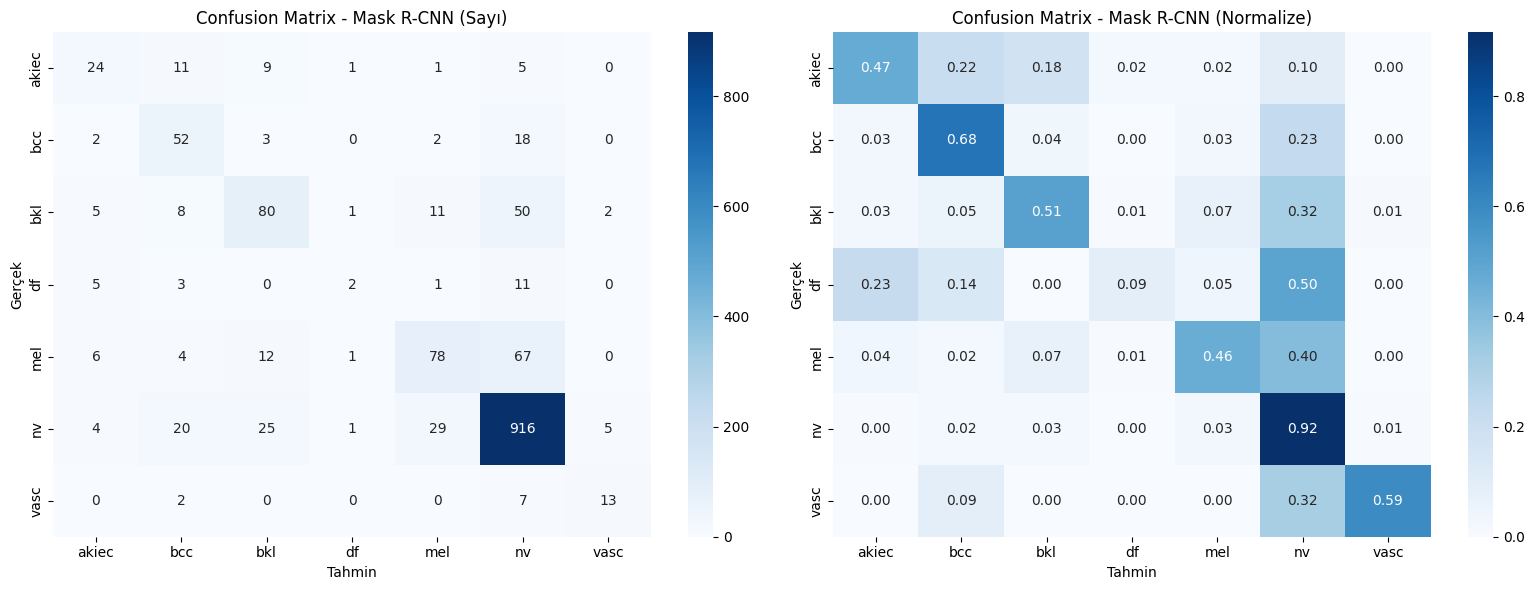

In [33]:
# ============================================================
# 26. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(test_labels, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[0])
axes[0].set_xlabel('Tahmin')
axes[0].set_ylabel('Gerçek')
axes[0].set_title('Confusion Matrix - Mask R-CNN (Sayı)')

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[1])
axes[1].set_xlabel('Tahmin')
axes[1].set_ylabel('Gerçek')
axes[1].set_title('Confusion Matrix - Mask R-CNN (Normalize)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_maskrcnn.png'),
            dpi=100, bbox_inches='tight')
plt.show()

In [34]:
# ============================================================
# 27. ÖZET
# ============================================================
print("=" * 60)
print("MASK R-CNN PIPELINE ÖZET")
print("=" * 60)
print(f"Veri seti: HAM10000 ({len(df)} görüntü, {N_CLASSES} sınıf)")
print(f"Maske kaynağı: Tschandl Lesion Segmentations (resmi GT)")
print(f"Train/Val/Test: {len(train_df)}/{len(val_df)}/{len(test_df)}")
print()
print(f"Optuna best params: {best_params}")
print(f"Optuna best val F1: {study.best_value:.4f}")
print()
print(f"FINAL TEST:")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  F1 (macro): {test_f1:.4f}")
print()
print(f"Çıktılar: {OUTPUT_DIR}")
print(f"  - {os.path.basename(MODEL_SAVE_PATH)} (model ağırlıkları)")
print(f"  - {os.path.basename(PROBS_SAVE_PATH)} (ensemble için)")
print(f"  - {os.path.basename(LABELS_SAVE_PATH)} (ensemble için)")
print(f"  - confusion_matrix_maskrcnn.png")
print(f"  - optuna_results_maskrcnn.png")

MASK R-CNN PIPELINE ÖZET
Veri seti: HAM10000 (10015 görüntü, 7 sınıf)
Maske kaynağı: Tschandl Lesion Segmentations (resmi GT)
Train/Val/Test: 7054/1464/1497

Optuna best params: {'lr': 0.00010725209743172001, 'dropout': 0.4909729556485983, 'weight_decay': 0.000462258900102083, 'batch_size': 4}
Optuna best val F1: 0.4025

FINAL TEST:
  Accuracy: 0.7782
  F1 (macro): 0.5464

Çıktılar: /content/output_maskrcnn
  - maskrcnn_best.pth (model ağırlıkları)
  - probabilities_maskrcnn.npy (ensemble için)
  - test_labels_maskrcnn.npy (ensemble için)
  - confusion_matrix_maskrcnn.png
  - optuna_results_maskrcnn.png


In [35]:
# ============================================================
# 28. DRIVE'A YEDEKLEME (KRİTİK — session ölmeden önce!)
# Tüm önemli dosyaları /content/drive/MyDrive/cilt_kanseri_ensemble/
# klasörüne kopyala. Session ölse bile dosyalar Drive'da kalır.
# ============================================================
import shutil

# CM_SAVE_PATH yoksa otomatik bul
cm_path = os.path.join(OUTPUT_DIR, 'confusion_matrix_maskrcnn.png')
optuna_png = os.path.join(OUTPUT_DIR, 'optuna_results_maskrcnn.png')

files_to_backup = [
    PROBS_SAVE_PATH,
    LABELS_SAVE_PATH,
    MODEL_SAVE_PATH,
    STUDY_SAVE_PATH,
    cm_path,
    optuna_png,
]

print('Drive\'a yedekleniyor...')
for src in files_to_backup:
    if os.path.exists(src):
        dst = os.path.join(DRIVE_OUTPUT, os.path.basename(src))
        shutil.copy2(src, dst)
        size_mb = os.path.getsize(dst) / 1024 / 1024
        print(f'  ✓ {os.path.basename(src)} ({size_mb:.2f} MB)')
    else:
        print(f'  ✗ BULUNAMADI: {src}')

print(f'\nDrive klasörü: {DRIVE_OUTPUT}')
print('\nİçindekiler:')
for f in sorted(os.listdir(DRIVE_OUTPUT)):
    full = os.path.join(DRIVE_OUTPUT, f)
    if os.path.isfile(full):
        size_mb = os.path.getsize(full) / 1024 / 1024
        print(f'  {f} ({size_mb:.2f} MB)')

print('\n🎉 Yedekleme tamamlandı! Artık session ölse bile dosyalar Drive\'da güvende.')

Drive'a yedekleniyor...
  ✓ probabilities_maskrcnn.npy (0.04 MB)
  ✓ test_labels_maskrcnn.npy (0.01 MB)
  ✓ maskrcnn_best.pth (175.52 MB)
  ✓ optuna_study.pkl (0.01 MB)
  ✓ confusion_matrix_maskrcnn.png (0.07 MB)
  ✓ optuna_results_maskrcnn.png (0.05 MB)

Drive klasörü: /content/drive/MyDrive/cilt_kanseri_ensemble

İçindekiler:
  best_efficientnet_b0.pth (18.10 MB)
  best_yolov8n_cls.pt (2.84 MB)
  confusion_matrix_efficientnet_b0.jpg (0.07 MB)
  confusion_matrix_maskrcnn.png (0.07 MB)
  confusion_matrix_yolov8n_cls.jpg (0.07 MB)
  maskrcnn_best.pth (175.52 MB)
  optuna_results_maskrcnn.png (0.05 MB)
  optuna_study.pkl (0.01 MB)
  optuna_study_efficientnet.pkl (0.02 MB)
  optuna_study_yolov8.pkl (0.02 MB)
  probabilities_efficientnet_b0.npy (0.04 MB)
  probabilities_maskrcnn.npy (0.04 MB)
  probabilities_yolov8n_cls.npy (0.04 MB)
  test_labels_efficientnet_b0.npy (0.01 MB)
  test_labels_maskrcnn.npy (0.01 MB)
  test_labels_yolov8n_cls.npy (0.01 MB)

🎉 Yedekleme tamamlandı! Artık sessio